<a href="https://colab.research.google.com/github/xyfuu/DailyChallanges/blob/main/Characterized_Learning_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CHARACTERIZED LEARNING - CLUSTERING

In [ ]:
import pandas as pd

df = pd.read_csv("sample_data/Mall_Customers.csv")
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [ ]:
df = df.rename(columns={'Gender': 'gender', 'Age':'age',
                        'Annual Income (k$)': 'annual_income',
                        'Spending Score (1-100)': 'spending_score'})
df['gender'].replace(['Female', 'Male'], [0,1], inplace=True)
df.head(3)

,CustomerID,gender,age,annual_income,spending_score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6


In [ ]:
from sklearn.cluster import KMeans


X = df.drop(['CustomerID', 'gender'], axis=1)

clusters = []
for i in range(1, 11):
  km = KMeans(n_clusters=i).fit(X)
  clusters.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

Text(0, 0.5, 'Inertia')

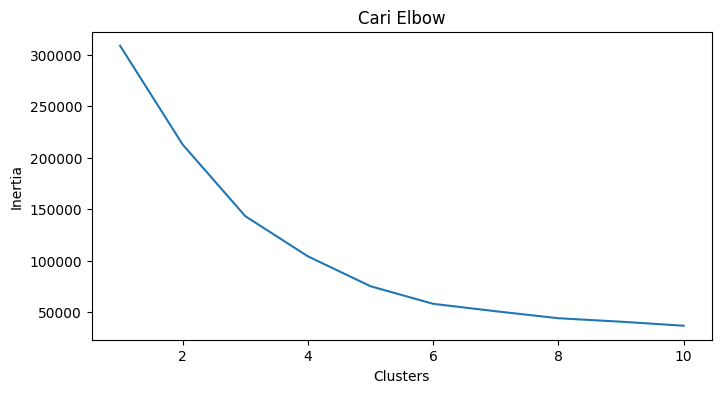

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Cari Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


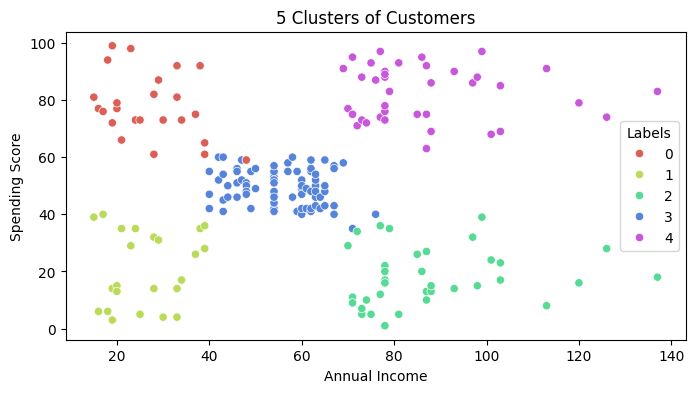

In [ ]:
km5 = KMeans(n_clusters=5).fit(X)
X['Labels'] = km5.labels_

plt.figure(figsize=(8, 4))
sns.scatterplot(x=X['annual_income'], y=X['spending_score'], hue=X['Labels'], palette = sns.color_palette('hls', 5), data=X)
plt.title('5 Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

#Bank Custommer Segmentation

In [ ]:
import pandas as pd

df = pd.read_csv("Cust_Segmentation.csv")

df['Defaulted'].fillna(0.0, inplace=True)
df['Total Debt'] = df['Card Debt'] + df['Other Debt']

df.head(3)

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio,Total Debt
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3,1.197
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8,12.800
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9,11.913


In [ ]:
from sklearn.cluster import KMeans

X = df.drop(['Customer Id', 'Address'], axis=1)

clusters = []
for i in range(1, 12):
  km = KMeans(n_clusters=i).fit(X)
  clusters.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

Text(0, 0.5, 'Inertia')

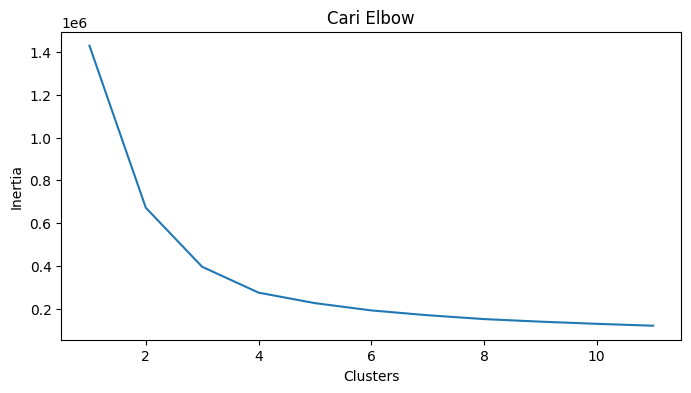

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=list(range(1, 12)), y=clusters, ax=ax)
ax.set_title('Cari Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')

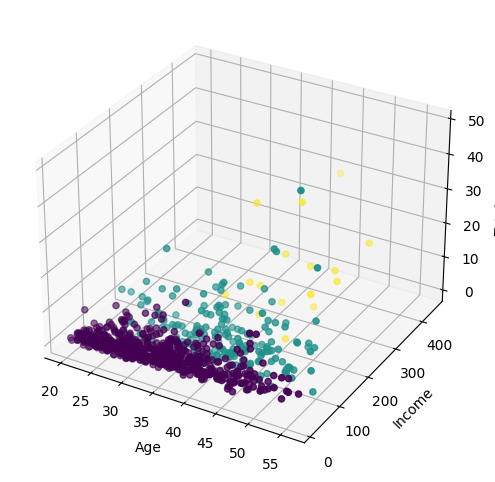

In [ ]:
km3 = KMeans(init = "k-means++", n_clusters = 3, n_init = 12).fit(X)
X['Labels'] = km3.labels_
X.groupby('Labels').mean()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6, 6))
plt.clf()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['Age'],df['Income'],df['Total Debt'], c = X['Labels'].astype(float))

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Total Debt')
plt.show()